In [1]:
import warnings  #TO REMOVE UNNESSASARY WARNINGS
#FOR ALL CODE NUMERICAL OPERATIONS, PLOTTINGS, REPRESENTATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

#VECTORIZING DATA FOR MODEL TO UNDERSTAND AND SPLITTING INTO TRAINING AND TESTING DATA
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

#ML MODEL
from sklearn.naive_bayes import MultinomialNB

#EVALUATE ACCURACY SCORES
from sklearn.metrics import accuracy_score, classification_report

import os                                               #THIS ITERATES THROUGH ALL FILES IN /kaggle/input/data directory
for dirname, _, filenames in os.walk('/kaggle/input'):  #AND ITS SUBDIRECTORIES AND PRINT PATH OF THE CSV FILE REQUIRED
    for filename in filenames:
        print(os.path.join(dirname, filename))

warnings.filterwarnings('ignore')                       #COMMMAND WHEN WARNINGS OCCUR

# 1.DATA

##### Train DATA

In [2]:
train_path = r"C:\Users\LOLLA SRIKANTH\Desktop\New folder (2)\2\i.MIN-BE 350\2024\intern\1.MovieGenreClassification\Genre Classification Dataset\data_set\train_data.txt"
train_data = pd.read_csv(train_path, sep=':::', names=['Title', 'Genre', 'Description'], engine='python')
print(train_data.describe())

                                 Title    Genre  \
count                            54214    54214   
unique                           54214       27   
top      Oscar et la dame rose (2009)    drama    
freq                                 1    13613   

                                              Description  
count                                               54214  
unique                                              54086  
top      Grammy - music award of the American academy ...  
freq                                                   12  


In [3]:
print(train_data.info())               #FINDING DATA TYPES IN TRAINING DATA
print(train_data.isnull().sum())       #FINDING NULLS OR MISSING VALUES

<class 'pandas.core.frame.DataFrame'>
Index: 54214 entries, 1 to 54214
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        54214 non-null  object
 1   Genre        54214 non-null  object
 2   Description  54214 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB
None
Title          0
Genre          0
Description    0
dtype: int64


##### TEST DATA

In [4]:
test_path = r"C:\Users\LOLLA SRIKANTH\Desktop\New folder (2)\2\i.MIN-BE 350\2024\intern\1.MovieGenreClassification\Genre Classification Dataset\data_set\test_data.txt"
test_data = pd.read_csv(test_path, sep=':::', names=['Id', 'Title', 'Description'], engine='python')
test_data.head()

,Id,Title,Description
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),Before he was known internationally as a mart...


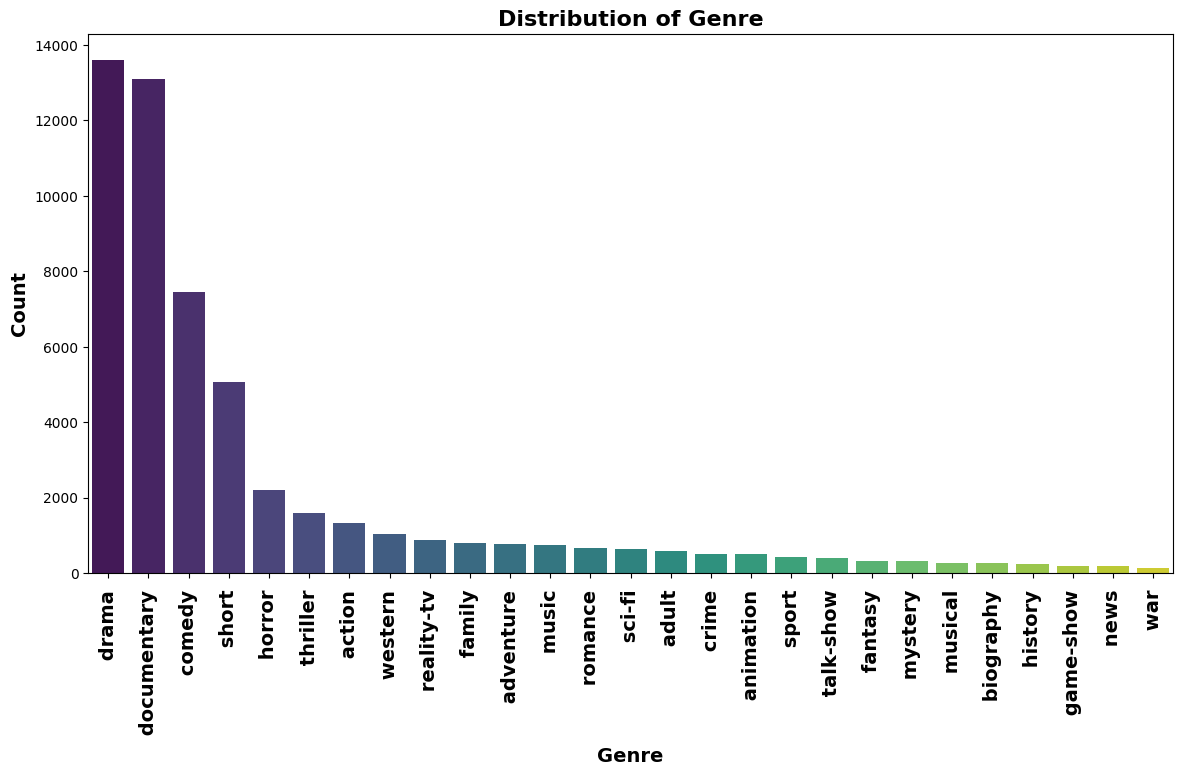

In [5]:
plt.figure(figsize=(14,7))
counts = train_data['Genre'].value_counts()
sns.barplot(x=counts.index, y=counts, palette='viridis')
plt.xlabel('Genre', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.title('Distribution of Genre', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=14, fontweight='bold')
plt.show()

# 2.DATA PREPROCESSING

In [6]:
stemmer = LancasterStemmer()                       #INTIALIZE STEMMER AND STOPWORDS
stop_words = set(stopwords.words('english'))

def clean_text(text):                              #CLEANING DATA
    text = text.lower()                            #ALL THE DATA IN LOWER CASE
    text = re.sub(r'@\S+', '', text)               #REMOVE ALL TWITTER HANDLES
    text = re.sub(r'http\S+', '', text)            #REMOVE URL'S
    text = re.sub(r'pic.\S+', '', text)            
    text = re.sub(r"[^a-zA-Z']+", '', text)        #KEEP ONLY CHARACTERS
    text = re.sub(r'\s+[a-zA-Z]\s+', '', text + ' ')#KEEP WORDS WITH LENGTH>1 ONLY
    
    text = "".join([i for i in text if i not in string.punctuation])
    words = nltk.word_tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')
    text = " ".join([i for i in words if i not in stopwords and len(i) > 2])    #REMOVE STOPWORDS
    text = re.sub("\s[\s]+", " ", text).strip()                                 #REPEATED/LEADING/TRAINLING SPACES

    return text

train_data['Text_cleaning'] = train_data['Description'].apply(clean_text)       #APPLYING THE CLEAN FUNCTION FOR TRAINING DATA
test_data['Text_cleaning'] = test_data['Description'].apply(clean_text)

##### MODIFIED DATA

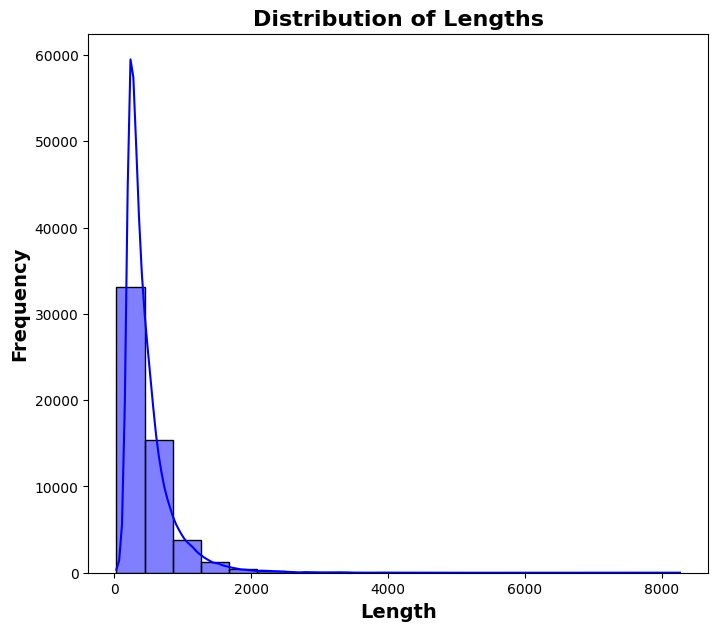

In [7]:
train_data['length_Text_cleaning'] = train_data['Text_cleaning'].apply(len)

#LABELING FOR THE REPRESENTATION PLOT SIZE,XANDY AXIS NAME, TITLE OF REPRESENTAION 
plt.figure(figsize=(8,7))
sns.histplot(data=train_data, x='length_Text_cleaning', bins=20, kde=True,color='blue')
plt.xlabel('Length', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Distribution of Lengths', fontsize=16, fontweight='bold')
plt.show()

# 3.VECTORIZING TEXT DATA AND SPLITTING DATA:: TRAINING AND TESTING

In [25]:
tfidf_vectorizer = TfidfVectorizer()

X_train = tfidf_vectorizer.fit_transform(train_data['Text_cleaning'])
X_test  = tfidf_vectorizer.transform(test_data['Text_cleaning'])



In [26]:
X =X_train
y = train_data['Genre']
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

# 4.ML Model 

In [27]:
classifier = MultinomialNB()                #INITIALIZE AND TRAIN THE MODEL
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_val)          #MAKE PREDICTION ON THE VALIDATION SET

accuracy = accuracy_score(y_val, y_pred)    #EVALUATE THE MODEL
print("Validation Accuracy:", accuracy)
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.2494697039564696
               precision    recall  f1-score   support

      action        0.00      0.00      0.00       263
       adult        0.00      0.00      0.00       112
   adventure        0.00      0.00      0.00       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.50      0.00      0.01      1443
       crime        0.00      0.00      0.00       107
 documentary        0.56      0.00      0.00      2659
       drama        0.25      1.00      0.40      2697
      family        0.00      0.00      0.00       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.00      0.00      0.00        40
     history        0.00      0.00      0.00        45
      horror        0.00      0.00      0.00       431
       music        0.00      0.00      0.00       144
     musical        0.00      0.00      0.00        50
     mystery        0.00

#### testing the model

In [28]:
X_test_predictions = classifier.predict(X_test)        #USE TO 
test_data['Predicted_Genre'] = X_test_predictions

test_data.to_csv('predicted_genres.csv', index=False)
print(test_data)

          Id                             Title  \
0          1             Edgar's Lunch (1998)    
1          2         La guerra de papá (1977)    
2          3      Off the Beaten Track (2010)    
3          4           Meu Amigo Hindu (2015)    
4          5                Er nu zhai (1955)    
...      ...                               ...   
54195  54196   "Tales of Light & Dark" (2013)    
54196  54197      Der letzte Mohikaner (1965)    
54197  54198              Oliver Twink (2007)    
54198  54199                Slipstream (1973)    
54199  54200        Curitiba Zero Grau (2010)    

                                             Description  \
0       L.R. Brane loves his life - his car, his apar...   
1       Spain, March 1964: Quico is a very naughty ch...   
2       One year in the life of Albin and his family ...   
3       His father has died, he hasn't spoken with hi...   
4       Before he was known internationally as a mart...   
...                                    